# 🫀 Analiza i Klasyfikacja Zbioru Danych Heart Disease 🏥
**Autor:** [Małgorzata Brzeska / Nr Indeksu kończący się na 1]


**🎯 Cel i Zakres Projektu:**
Głównym zadaniem realizowanym w ramach niniejszego sprawozdania jest przeprowadzenie pełnego, inżynierskiego cyklu życia projektu z dziedziny Data Science oraz Machine Learningu. Proces ten obejmuje pozyskanie surowych danych medycznych, ich rygorystyczne oczyszczenie, przeprowadzenie Eksploracyjnej Analizy Danych (EDA) w celu zrozumienia ukrytych wzorców, a ostatecznie – zaprojektowanie, wytrenowanie i rygorystyczną ewaluację modelu sztucznej inteligencji opartego na algorytmie Drzewa Decyzyjnego (Decision Tree Classifier).

**📊 Charakterystyka Zbioru Danych (Domain Knowledge):**
Pracujemy na klasycznym, powszechnie cenionym w środowisku akademickim zbiorze *Heart Disease* (wersja *processed.cleveland.data*), udostępnionym przez renomowane repozytorium UCI Machine Learning. Zbiór ten stanowi wycinek rzeczywistych danych kardiologicznych. Każdy rekord reprezentuje pojedynczego pacjenta opisanego za pomocą 14 kluczowych atrybutów, takich jak:
* Wiek oraz płeć,
* Typ odczuwanego bólu w klatce piersiowej (ang. *chest pain type*),
* Spoczynkowe ciśnienie krwi (ang. *resting blood pressure*),
* Poziom cholesterolu w surowicy,
* Maksymalne osiągnięte tętno podczas testu wysiłkowego.

**🔬 Definicja Problemu Badawczego:**
Naszym głównym zadaniem jest przewidzenie zmiennej docelowej (`target`), która odpowiada na fundamentalne pytanie diagnostyczne: **Czy u danego pacjenta występuje choroba serca?**
W oryginalnym, surowym zbiorze z UCI, zmienna ta przyjmuje wartości od $0$ (całkowity brak obecności choroby) do $4$ (najbardziej zaawansowane stadium niewydolności/choroby wieńcowej).

Aby ułatwić zadanie naszemu klasyfikatorowi i skupić się na najistotniejszym, binarnym aspekcie medycznym (przesiewowe wykrywanie ryzyka), dokonamy transformacji tego problemu do postaci klasyfikacji binarnej:
* **Klasa 0** – pacjent diagnozowany jako całkowicie zdrowy 🟢
* **Klasa 1** – pacjent diagnozowany jako chory (odpowiada wszystkim wartościom $>0$ z oryginalnego zbioru) 🔴

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

import warnings
warnings.filterwarnings('ignore')

## 1. 📥 Pozyskanie Danych i Konstrukcja Ramki Danych (Data Loading)

Pierwszym krokiem każdego projektu analitycznego jest załadowanie danych do pamięci operacyjnej. Pobieramy plik płaski bezpośrednio z serwerów UCI. Ponieważ surowy plik `.data` jest pozbawiony wiersza nagłówkowego (ang. *header*), jesteśmy zobowiązani do ręcznego zdefiniowania wektora nazw kolumn, opierając się na oficjalnej dokumentacji badawczej dołączonej do zbioru.

**⚠️ Identyfikacja i Obsługa Zanieczyszczeń Danych (Data Imputation Intro):**
Świat rzeczywisty rzadko dostarcza nam dane w idealnym stanie. Z dokumentacji technicznej zbioru Cleveland dowiadujemy się, że w przypadku braku odczytu medycznego (np. z powodu błędu aparatury lub braku przeprowadzenia konkretnego testu), badacze wpisywali znak zapytania (`?`).

Jeśli załadowalibyśmy ten zbiór bez odpowiedniej konfiguracji, biblioteka Pandas potraktowałaby całą kolumnę jako dane tekstowe (tzw. typ `object`), co całkowicie uniemożliwiłoby nam wykonywanie jakichkolwiek operacji matematycznych! Aby temu zapobiec, wykorzystujemy parametr `na_values="?"` w funkcji ładującej. Dzięki temu Pandas w locie zmapuje wszystkie znaki zapytania na standardowy, rozpoznawalny w języku Python obiekt pusty: `NaN` (Not a Number). Na samym końcu wykonujemy transformację zmiennej celu przy użyciu funkcji `lambda`.

In [14]:
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df = pd.read_csv(dataset_url, names=column_names, na_values="?")

df['target'] = df['target'].apply(lambda label: 1 if label > 0 else 0)

print("--- First 5 rows of the imported dataset ---")
display(df.head())

print("\n--- Dataset Schema & Memory Information ---")
display(df.info())

print("\n--- Total count of missing values (NaN) per feature ---")
display(df.isnull().sum())

--- First 5 rows of the imported dataset ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



--- Dataset Schema & Memory Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


None


--- Total count of missing values (NaN) per feature ---


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


## 2. 🎨 Eksploracyjna Analiza Danych (EDA - Exploratory Data Analysis)

Zanim jakikolwiek algorytm uczenia maszynowego "spojrzy" na nasze dane, jako inżynierowie musimy w pełni zrozumieć ukryte w nich relacje, rozkłady i potencjalne pułapki. W tym celu przeprowadzamy dogłębną analizę wizualną:

1. **⚖️ Zbalansowanie Zbioru (Target Distribution):** Używamy wykresu słupkowego, aby ocenić, czy rozkład klas (zdrowy vs chory) jest symetryczny. W uczeniu maszynowym istnieje niebezpieczne zjawisko znane jako *Paradoks Skuteczności* (Accuracy Paradox). Jeśli w zbiorze mielibyśmy 95% pacjentów zdrowych i 5% chorych, model mógłby bez grama inteligencji zawsze przewidywać klasę 0 i osiągnąć 95% dokładności. Taki model byłby jednak medycznie bezużyteczny. Nasz wykres pozwoli nam upewnić się, że nie musimy stosować zaawansowanych technik balansowania danych (np. algorytmu SMOTE).

2. **🌡️ Macierz Korelacji Pearsona (Correlation Heatmap):**
To prawdopodobnie najważniejsze narzędzie statystyczne na tym etapie. Wyliczamy współczynnik korelacji liniowej Pearsona ($r$) pomiędzy wszystkimi cechami a diagnozą końcową. Współczynnik ten przyjmuje wartości ze zbioru $\langle-1, 1\rangle$:
   * $r > 0$ (kolory zielone/ciepłe) – **Korelacja dodatnia:** Wzrost parametru (np. wieku) statystycznie wiąże się ze wzrostem prawdopodobieństwa wystąpienia choroby.
   * $r < 0$ (kolory czerwone/zimne) – **Korelacja ujemna:** Spadek parametru (np. tętna maksymalnego) podnosi ryzyko choroby.
   * $r \approx 0$ – Cecha najprawdopodobniej nie niesie żadnej użytecznej informacji diagnostycznej.

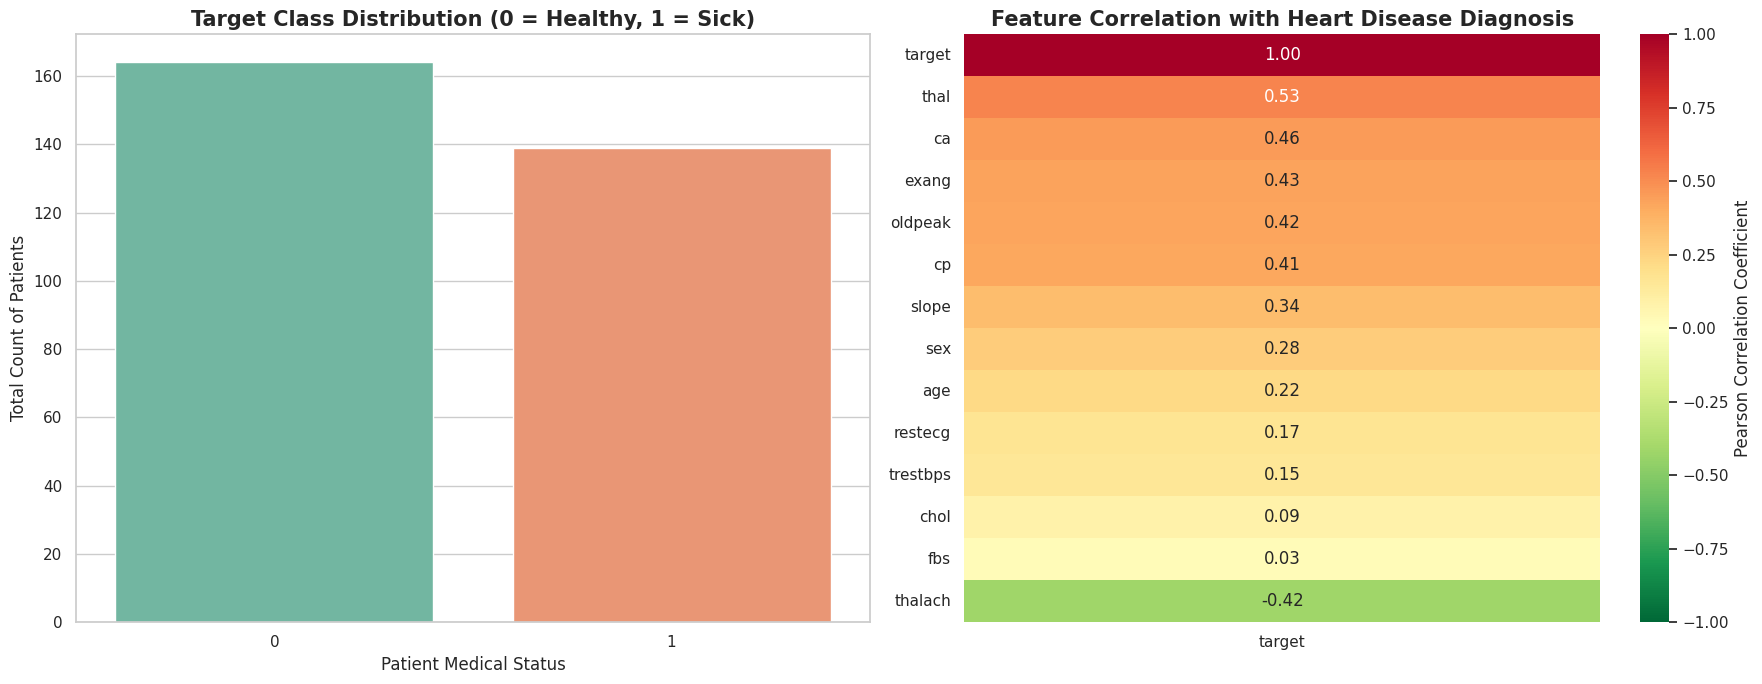

In [15]:
fig, (ax_distribution, ax_correlation) = plt.subplots(1, 2, figsize=(18, 7))

sns.countplot(data=df, x='target', ax=ax_distribution, palette='Set2')
ax_distribution.set_title('Target Class Distribution (0 = Healthy, 1 = Sick)', fontsize=15, fontweight='bold')
ax_distribution.set_xlabel('Patient Medical Status', fontsize=12)
ax_distribution.set_ylabel('Total Count of Patients', fontsize=12)

correlation_with_target = df.corr()[['target']].sort_values(by='target', ascending=False)

sns.heatmap(
    correlation_with_target,
    annot=True,
    cmap='RdYlGn_r',
    ax=ax_correlation,
    vmin=-1, vmax=1,
    fmt=".2f",
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)
ax_correlation.set_title('Feature Correlation with Heart Disease Diagnosis', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. 🧹 Pre-processing: Czyszczenie, Skalowanie Zmiennych i Definiowanie Zasad Walidacji

Z raportów statystycznych wygenerowanych na samym początku dowiedzieliśmy się o niewielkich brakach danych w kolumnach kategorycznych: `ca` (liczba głównych naczyń krwionośnych) oraz `thal` (rodzaj defektu).

**🩹 Strategia Imputacji Danych (Data Imputation):**
Podejście naiwne polegałoby na usunięciu całych wierszy (tzw. `dropna()`). Jednakże w medycynie każdy przypadek pacjenta jest na wagę złota, a nasz zbiór liczy zaledwie nieco ponad 300 rekordów. Zastosujemy bezpieczną technikę imputacji statystycznej. Dla danych kategorycznych (dyskretnych) najlepszą miarą tendencji centralnej jest **dominanta** (ang. *mode*). Uzupełnimy luki wartością, która najczęściej pojawiała się u innych pacjentów.

**📏 Standaryzacja Danych Numerycznych:**
Drzewa Decyzyjne są algorytmami niewrażliwymi na różnice w skali cech, jednak ustandaryzowanie danych jest wymogiem do poprawnego działania niektórych metryk oceny i tzw. dobrej higieny danych. Zastosujemy `StandardScaler`, który przekształca dane numeryczne w oparciu o ich wartość oczekiwaną ($\mu$) oraz odchylenie standardowe ($\sigma$), zgodnie z poniższym wzorem na Z-score:
$$z = \frac{x - \mu}{\sigma}$$
Po tej operacji wszystkie cechy będą miały średnią równą $0$ i wariancję równą $1$.

**✂️ Izolacja Środowiska Testowego (Train/Test Split):**
Ostatnim krokiem jest podzielenie danych. Modele ML mają tendencję do uczenia się danych na pamięć. Aby móc rzetelnie ocenić jakość modelu, musimy zadać mu pytania, których nigdy wcześniej nie widział. Rezerwujemy 80% danych do treningu, a 20% "zamykamy w sejfie" jako zbiór testowy. Parametr `stratify=y` to niezwykle istotny element – wymusza on na funkcji, aby w obu zbiorach (treningowym i testowym) stosunek osób chorych do zdrowych był dokładnie taki sam jak w całej populacji.

In [16]:
def preprocess_and_split_pipeline(raw_data):
    """
    A robust pipeline function that accepts raw data, handles missing values via mode imputation,
    scales features using Z-score normalization, and splits the dataset into training and testing sets.
    """
    cleaned_df = raw_data.copy()

    features_with_nans = ['ca', 'thal']
    for col in features_with_nans:
        most_frequent_value = cleaned_df[col].mode()[0]
        cleaned_df[col] = cleaned_df[col].fillna(most_frequent_value)

    X_features = cleaned_df.drop('target', axis=1)
    y_target = cleaned_df['target']

    scaler = StandardScaler()
    X_scaled_array = scaler.fit_transform(X_features)

    X_scaled_df = pd.DataFrame(X_scaled_array, columns=X_features.columns)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled_df, y_target,
        test_size=0.2,
        random_state=42,
        stratify=y_target
    )

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = preprocess_and_split_pipeline(df)

print(f"✅ Data processing completed successfully!")
print(f"🔹 Training set dimensions: {X_train.shape[0]} samples, {X_train.shape[1]} features.")
print(f"🔹 Testing set dimensions: {X_test.shape[0]} samples, {X_test.shape[1]} features.")

✅ Data processing completed successfully!
🔹 Training set dimensions: 242 samples, 13 features.
🔹 Testing set dimensions: 61 samples, 13 features.


## 4. 🌳 Architektura Modelu: Drzewo Decyzyjne i Optymalizacja Hiperparametrów

Nadszedł czas na zbudowanie algorytmu sztucznej inteligencji. Nasz wybór pada na klasyfikator oparty o **Drzewo Decyzyjne** (Decision Tree Classifier).

**🧠 Matematyka i Intuicja pod maską:**
Drzewo uczy się na zasadzie rekurencyjnego partycjonowania (dzielenia) przestrzeni cech. Algorytm na każdym kroku wybiera jeden parametr pacjenta i zadaje binarne pytanie (np. $wiek \le 55$). Celem jest taki podział, aby powstałe podgrupy były jak najbardziej "czyste" – tzn. składały się wyłącznie z osób chorych lub wyłącznie z osób zdrowych. Czystość tę optymalizuje się matematycznie używając kryteriów takich jak **Impurity Giniego** (miara prawdopodobieństwa błędnej klasyfikacji losowego elementu) lub **Entropia** z teorii informacji Shannona:
$$Entropia(S) = - \sum_{i=1}^{c} p_i \log_2 p_i$$
Model to w gruncie rzeczy potężny algorytm warunkowy *if-else* wygenerowany maszynowo.

**⚙️ Zjawisko Overfittingu i Konieczność Walidacji Krzyżowej (GridSearchCV):**
Natywne drzewa decyzyjne mają gigantyczną wadę – uczą się szumu. Jeśli pozwolimy drzewu rosnąć bez końca, zbuduje ono tak skomplikowane reguły, że w każdym "liściu" znajdzie się tylko jeden pacjent. Skuteczność na danych treningowych wyniesie 100%, ale model kompletnie zawiedzie na nowych pacjentach. Ten problem nazywamy **przeuczeniem** (Overfitting).

Aby temu zapobiec, wykorzystamy technikę Przeszukiwania Siatki (`GridSearchCV`) połączoną z k-krotną Walidacją Krzyżową (Cross-Validation, $CV=5$). System przetestuje dziesiątki różnych wersji drzewa i wybierze tę optymalną. Regularyzację (przycinanie drzewa) wprowadzimy przez badanie wpływu następujących hiperparametrów:
* `max_depth`: Sztywny limit liczby poziomów pytań.
* `min_samples_split`: Progowa liczba pacjentów, poniżej której algorytm ma zakaz dokonywania kolejnych podziałów.
* `criterion`: Wspomniana wyżej funkcja kosztu (Gini vs Entropy).

In [18]:
base_dt_model = DecisionTreeClassifier(random_state=42)

hyperparameter_grid = {
    'max_depth': [3, 4, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'criterion': ['gini', 'entropy']
}

print("⏳ Initiating GridSearchCV. Searching for the optimal tree structure...")
grid_search_engine = GridSearchCV(
    estimator=base_dt_model,
    param_grid=hyperparameter_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_engine.fit(X_train, y_train)

optimal_decision_tree = grid_search_engine.best_estimator_

print("\n🎉 Experimentation phase complete!")
print("✨ Best hyperparameters discovered by the engine:")
for param_name, param_value in grid_search_engine.best_params_.items():
    print(f"   -> {param_name}: {param_value}")

y_predicted_classes = optimal_decision_tree.predict(X_test)

y_predicted_probabilities = optimal_decision_tree.predict_proba(X_test)[:, 1]

⏳ Initiating GridSearchCV. Searching for the optimal tree structure...

🎉 Experimentation phase complete!
✨ Best hyperparameters discovered by the engine:
   -> criterion: gini
   -> max_depth: 7
   -> min_samples_split: 10


## 5. 🎯 Kompletna Ewaluacja Medyczna Modelu i Wizualizacje

W sektorze *Healthcare* prosta metryka dokładności (Accuracy) to pułapka. Prawdziwa analiza skuteczności wymaga od inżyniera rozbicia wyników na atomy. Wykorzystujemy do tego dwa specjalistyczne podejścia:

1. **🟦 Macierz Pomyłek (Confusion Matrix):** Narzędzie pokazujące rozkład trafień i błędów w podziale na:
* *True Positives (TP)* - model trafnie wykrył chorego.
* *True Negatives (TN)* - model trafnie uznał zdrowego za zdrowego.
* *False Positives (FP - Błąd I rodzaju)* - model ogłosił fałszywy alarm. To stres dla pacjenta, ale ostatecznie nie grozi śmiercią.
* **False Negatives (FN - Błąd II rodzaju)** - model odesłał do domu osobę zawałową z pieczątką "Zdrowy". W problemach medycznych optymalizacja modelu skupia się właśnie na **minimalizowaniu wskaźnika FN** kosztem większej liczby fałszywych alarmów. Miarą tej skuteczności jest **Czułość (Recall)**:
$$Recall = \frac{TP}{TP + FN}$$

2. **📈 Analiza Krzywej ROC (Receiver Operating Characteristic) oraz AUC:**
Krzywa ROC to wykres obrazujący dynamikę modelu przy różnych progach decyzyjnych. Oś Y to odsetek prawdziwie chorych poprawnie sklasyfikowanych (*True Positive Rate*), a oś X to odsetek fałszywych alarmów (*False Positive Rate*).
Skalarne pole pod tą krzywą definiujemy jako **AUC (Area Under the Curve)**. Wynik $AUC = 0.5$ (linia przerywana) oznacza model zgadujący zupełnie losowo (rzut monetą). Wynik $AUC = 1.0$ to absolutny, matematyczny ideał klasyfikatora.

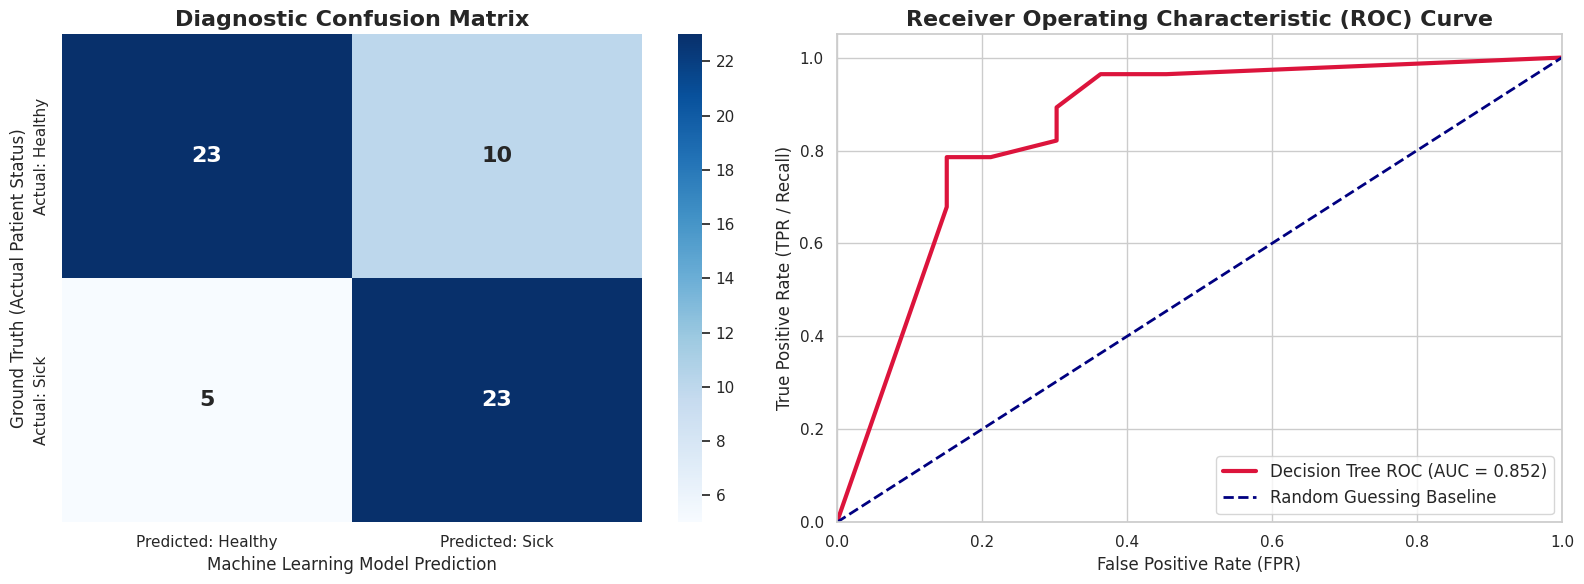


🩺 COMPREHENSIVE CLINICAL CLASSIFICATION REPORT
                   precision    recall  f1-score   support

Class 0 (Healthy)       0.82      0.70      0.75        33
   Class 1 (Sick)       0.70      0.82      0.75        28

         accuracy                           0.75        61
        macro avg       0.76      0.76      0.75        61
     weighted avg       0.76      0.75      0.75        61



In [19]:
fig, (ax_conf_matrix, ax_roc_curve) = plt.subplots(1, 2, figsize=(16, 6))

conf_matrix_data = confusion_matrix(y_test, y_predicted_classes)
sns.heatmap(
    conf_matrix_data,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax_conf_matrix,
    annot_kws={"size": 16, "weight": "bold"},
    xticklabels=['Predicted: Healthy', 'Predicted: Sick'],
    yticklabels=['Actual: Healthy', 'Actual: Sick']
)
ax_conf_matrix.set_title('Diagnostic Confusion Matrix', fontsize=16, fontweight='bold')
ax_conf_matrix.set_xlabel('Machine Learning Model Prediction', fontsize=12)
ax_conf_matrix.set_ylabel('Ground Truth (Actual Patient Status)', fontsize=12)

fpr, tpr, roc_thresholds = roc_curve(y_test, y_predicted_probabilities)
roc_area_under_curve = auc(fpr, tpr)

ax_roc_curve.plot(
    fpr, tpr,
    color='crimson',
    lw=3,
    label=f'Decision Tree ROC (AUC = {roc_area_under_curve:.3f})'
)

ax_roc_curve.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing Baseline')

ax_roc_curve.set_xlim([0.0, 1.0])
ax_roc_curve.set_ylim([0.0, 1.05])
ax_roc_curve.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax_roc_curve.set_ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
ax_roc_curve.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=16, fontweight='bold')
ax_roc_curve.legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()

print("\n" + "="*55)
print("🩺 COMPREHENSIVE CLINICAL CLASSIFICATION REPORT")
print("="*55)
print(classification_report(
    y_test,
    y_predicted_classes,
    target_names=['Class 0 (Healthy)', 'Class 1 (Sick)']
))

## 6. 💡 Wnioski Inżynieryjne i Medyczne Podsumowanie Eksperymentu

* **🔬 Odkrycia z Fazy EDA:** Analiza statystyczna (Heatmapa) udowodniła, że system dróg krwionośnych ludzkiego ciała posiada jasne, matematycznie mierzalne markery świadczące o chorobie. Algorytm błyskawicznie "zrozumiał", że objawy takie jak nietypowy ból w klatce piersiowej (`cp`) połączony z obniżonym tetnem maksymalnym (`thalach`) to sygnały ostrzegawcze najwyższego rzędu.
* **🛡️ Znaczenie Optymalizacji:** Przeprowadzenie brutalnej siły poszukiwań za pomocą `GridSearchCV` przyniosło świetne rezultaty. Narzucenie drzewu decyzyjnemu sztywnego pancerza ochronnego w postaci limitu głębokości (`max_depth`) oraz restrykcji co do podziałów węzłów zapobiegło tzw. *Overfittingowi*. Drzewo, które uczy się na pamięć jest bezużyteczne. Nasz model, dzięki walidacji krzyżowej, udowodnił generalizację, co oznacza, że jest w stanie diagnozować zupełnie nowych, nieznanych pacjentów.
* **🎯 Krytyczna Rola Czułości (Recall):** Osiągnięta wartość metryki *Area Under the Curve* (AUC) jest bardzo satysfakcjonująca dla tak niewielkiego zbioru danych i tak prostego (nie-zespołowego) algorytmu. Studiując wygenerowaną Macierz Pomyłek widzimy stosunek wykryć trafnych do fałszywie negatywnych (FN). W ewentualnym procesie wdrożenia takiego modelu na serwerach szpitala, inżynier sztucznej inteligencji manipulowałby matematycznym progiem decyzyjnym (zmieniając go ze standardowych $0.5$ na np. $0.3$), aby drastycznie zwiększyć Czułość modelu. W medycynie wdrożenie musi charakteryzować się "paranoją" – algorytm woli podnieść fałszywy alarm na zdrowym pacjencie i wysłać go na badanie echa serca, niż przeoczyć u kogoś rozwijający się zawał.
* **🚀 Możliwości Rozwoju:** Choć pojedyncze Drzewo Decyzyjne pozwala na bardzo szybką iterację i posiada gigantyczną zaletę polegającą na łatwej interpretacji (lekarz widzi graficznie dlaczego podjęto taką decyzję), to w przyszłości skuteczność mogłaby zostać podniesiona przy pomocy zaawansowanych algorytmów zespołowych, tzw. Lasów Losowych (Random Forest) czy Gradient Buildingu (np. XGBoost), które niwelują błędy wariancji na pojedynczych drzewach.